# **SVR (Support Vector Regression)**

> Our model uses a `linear` kernel.

<br>


---

<br>


> ## SVR Kernel List :

`LINEAR SVR KERNEL : linear`

<br> 


```
NON-LINEAR SVR KERNEL :
Polynomial Kernel
RBF (Radial Basis Function) Kernel
Sigmoid Kernel
```
Best Non-Linear SVC Kernel: `*RBF*` for non-linear problems, as it can handle complex boundaries and works well in most cases.

<br>

---

<br>


> ## What is Linear SVR and Non Linear SVR ?

`Linear SVR :`
- Think of a straight line (or a flat plane in higher dimensions) that fits data points.
- If the data can be approximated by a straight line, Linear SVR works perfectly.

- Example:
    - Imagine you are predicting the temperature for the next day based on previous days. If the temperature change is fairly consistent (linear), Linear SVR will give a good fit.
    - The data points align in a straight line, so a simple straight line (linear) fits the data.


<br>

`Non Linear SVR : `
- Think of a curve or complex shape that fits the data points.
- If the data is such that a straight line can't represent the relationship, Non-Linear SVR uses kernels (mathematical tricks) to fit complex curves or boundaries.
- Example:
    - Imagine predicting the price of a product based on seasonal demand. The relationship between season and price could be cyclical or non-linear.
    - A curved line is needed to capture the cyclical relationship between season and price.


<br>

---

<br>

> ## What is C in SVR ?

Answer: C is a parameter that controls the trade-off between achieving a low error on the training data and maintaining a simpler model. A high C value makes the model focus on minimizing misclassification, potentially leading to overfitting. A low C value allows some errors but helps the model generalize better, leading to a smoother decision boundary. In short, C adjusts the model's flexibility

<br>

---

In [1]:
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import LinearSVC

In [2]:
df = pd.read_csv('/content/21_laptop_prices.csv')

In [3]:
df.head()

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650


In [4]:
df.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'Ram', 'OS', 'Weight',
       'Price_euros', 'Screen', 'ScreenW', 'ScreenH', 'Touchscreen',
       'IPSpanel', 'RetinaDisplay', 'CPU_company', 'CPU_freq', 'CPU_model',
       'PrimaryStorage', 'SecondaryStorage', 'PrimaryStorageType',
       'SecondaryStorageType', 'GPU_company', 'GPU_model'],
      dtype='object')

In [5]:
df.shape

(1275, 23)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   object 
 1   Product               1275 non-null   object 
 2   TypeName              1275 non-null   object 
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   object 
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   object 
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   object 
 12  IPSpanel              1275 non-null   object 
 13  RetinaDisplay         1275 non-null   object 
 14  CPU_company           1275 non-null   object 
 15  CPU_freq             

In [7]:
df.describe()

,Inches,Ram,Weight,Price_euros,ScreenW,ScreenH,CPU_freq,PrimaryStorage,SecondaryStorage
count,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000,1275.000000
mean,15.022902,8.440784,2.040525,1134.969059,1900.043922,1073.904314,2.302980,444.517647,176.069020
std,1.429470,5.097809,0.669196,700.752504,493.346186,283.883940,0.503846,365.537726,415.960655
min,10.100000,2.000000,0.690000,174.000000,1366.000000,768.000000,0.900000,8.000000,0.000000
25%,14.000000,4.000000,1.500000,609.000000,1920.000000,1080.000000,2.000000,256.000000,0.000000
50%,15.600000,8.000000,2.040000,989.000000,1920.000000,1080.000000,2.500000,256.000000,0.000000
75%,15.600000,8.000000,2.310000,1496.500000,1920.000000,1080.000000,2.700000,512.000000,0.000000
max,18.400000,64.000000,4.700000,6099.000000,3840.000000,2160.000000,3.600000,2048.000000,2048.000000


In [8]:
le = LabelEncoder()
df['Company'] = le.fit_transform(df['Company'])
df['Product'] = le.fit_transform(df['Product'])
df['TypeName'] = le.fit_transform(df['TypeName'])
df['OS'] = le.fit_transform(df['OS'])
df['Screen'] = le.fit_transform(df['Screen'])
df['Touchscreen'] = le.fit_transform(df['Touchscreen'])
df['IPSpanel'] = le.fit_transform(df['IPSpanel'])
df['RetinaDisplay'] = le.fit_transform(df['RetinaDisplay'])
df['CPU_company'] = le.fit_transform(df['CPU_company'])
df['CPU_model'] = le.fit_transform(df['CPU_model'])
df['PrimaryStorage'] = le.fit_transform(df['PrimaryStorage'])
df['SecondaryStorageType'] = le.fit_transform(df['SecondaryStorageType'])
df['PrimaryStorageType'] = le.fit_transform(df['PrimaryStorageType'])
df['GPU_company'] = le.fit_transform(df['GPU_company'])
df['GPU_model'] = le.fit_transform(df['GPU_model'])

In [9]:
X = df.drop(["Price_euros", "Product"], axis = 1)
Y = df['Price_euros']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size = 0.2)

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
# Create and train SVR model
from sklearn.svm import SVR

svr_model = SVR(kernel='linear', C=5, epsilon=0.1)
svr_model.fit(X_train, y_train)

SVR(C=5, kernel='linear')

In [13]:
y_pred = svr_model.predict(X_test)

In [14]:
# Evaluate
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [15]:
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Squared Error: 115331.09
R^2 Score: 0.71


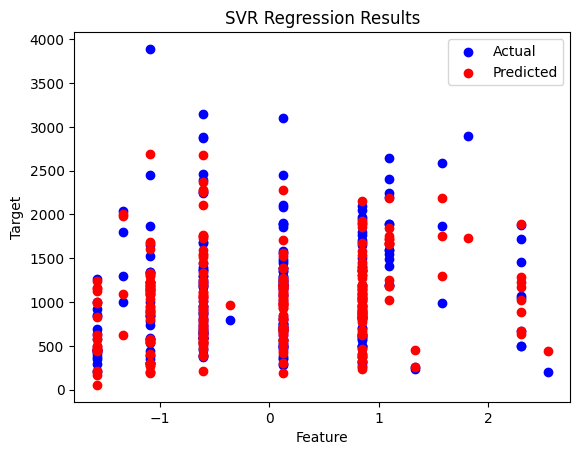

In [16]:
# Plot Result
import matplotlib.pyplot as plt

# Assuming X_test has multiple features, we'll plot against the first feature
plt.scatter(X_test[:, 0], y_test, color='blue', label='Actual')
plt.scatter(X_test[:, 0], y_pred, color='red', label='Predicted')
plt.legend()
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('SVR Regression Results')
plt.show()